In [1]:
!pip install pandas 
!pip install numpy 
!pip install matplotlib
!pip install seaborn 

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [7]:
patients = pd.read_csv("patients.csv")
visits = pd.read_csv("visits.csv")
admissions = pd.read_csv("admissions.csv")
doctors = pd.read_csv("doctors.csv")
lab_tests = pd.read_csv("lab_tests.csv")
prescriptions = pd.read_csv("prescriptions.csv")
staff = pd.read_csv("staff.csv")

In [8]:
patients.head()

,Patient_ID,Patient_Name,Gender,Age,City,Insurance,Registration_Date
0,1000001,Patient_0,Male,85.0,Hyderabad,Corporate,23/09/2021 05:46
1,1000002,Patient_1,Female,83.0,Pune,Private,05/10/2023 18:04
2,1000003,Patient_2,Male,90.0,Kolkata,Self Pay,13/05/2020 03:38
3,1000004,Patient_3,Female,12.0,Mumbai,Government,13/04/2022 21:14
4,1000005,Patient_4,Female,32.0,Delhi,Private,30/10/2024 11:16


In [9]:
patients.tail()

,Patient_ID,Patient_Name,Gender,Age,City,Insurance,Registration_Date
49995,1049996,Patient_49995,Male,85.0,Pune,Self Pay,09/10/2022 19:56
49996,1049997,Patient_49996,Female,15.0,Chennai,Corporate,24/12/2024 01:44
49997,1049998,Patient_49997,Female,18.0,Bengaluru,Government,06/01/2023 14:19
49998,1049999,Patient_49998,Female,13.0,Pune,Government,14/08/2020 10:46
49999,1050000,Patient_49999,Female,3.0,Pune,Self Pay,18/05/2018 11:26


In [10]:
patients["Gender"].unique()

<ArrowStringArray>
[   'Male',  'Female',   'Other',  'FEMALE',       nan, 'Female ',   'Male ',
   'OTHER',  'Other ',    'MALE', 'FEMALE ',  'OTHER ',   'MALE ']
Length: 13, dtype: str

In [11]:
# Clean Gender column
patients["Gender"] = (
    patients["Gender"]
    .astype("string")
    .str.strip()
    .str.title()
)

In [12]:
patients["Gender"].unique()

<ArrowStringArray>
['Male', 'Female', 'Other', <NA>]
Length: 4, dtype: string

In [13]:
patients.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         50000 non-null  int64  
 1   Patient_Name       49800 non-null  str    
 2   Gender             49800 non-null  string 
 3   Age                49800 non-null  float64
 4   City               50000 non-null  str    
 5   Insurance          50000 non-null  str    
 6   Registration_Date  50000 non-null  str    
dtypes: float64(1), int64(1), str(4), string(1)
memory usage: 5.0 MB


In [14]:
patients.shape

(50000, 7)

In [15]:
patients.columns

Index(['Patient_ID', 'Patient_Name', 'Gender', 'Age', 'City', 'Insurance',
       'Registration_Date'],
      dtype='str')

In [16]:
patients.describe()

,Patient_ID,Age
count,5.000000e+04,49800.000000
mean,1.025000e+06,45.077932
std,1.443390e+04,26.314374
min,1.000001e+06,0.000000
25%,1.012501e+06,22.000000
50%,1.025000e+06,45.000000
75%,1.037500e+06,68.000000
max,1.050000e+06,90.000000


In [17]:
patients.isnull().sum()

Patient_ID             0
Patient_Name         200
Gender               200
Age                  200
City                   0
Insurance              0
Registration_Date      0
dtype: int64

In [18]:
patients.isnull().mean()*100

Patient_ID           0.0
Patient_Name         0.4
Gender               0.4
Age                  0.4
City                 0.0
Insurance            0.0
Registration_Date    0.0
dtype: float64

In [19]:
patients.duplicated().sum()

np.int64(0)

In [20]:
patients.head()

,Patient_ID,Patient_Name,Gender,Age,City,Insurance,Registration_Date
0,1000001,Patient_0,Male,85.0,Hyderabad,Corporate,23/09/2021 05:46
1,1000002,Patient_1,Female,83.0,Pune,Private,05/10/2023 18:04
2,1000003,Patient_2,Male,90.0,Kolkata,Self Pay,13/05/2020 03:38
3,1000004,Patient_3,Female,12.0,Mumbai,Government,13/04/2022 21:14
4,1000005,Patient_4,Female,32.0,Delhi,Private,30/10/2024 11:16


In [21]:
patients["Insurance"].unique()

<ArrowStringArray>
['Corporate', 'Private', 'Self Pay', 'Government']
Length: 4, dtype: str

In [22]:
patients["City"].unique()

<ArrowStringArray>
['Hyderabad', 'Pune', 'Kolkata', 'Mumbai', 'Delhi', 'Bengaluru', 'Chennai']
Length: 7, dtype: str

In [23]:
patients["Gender"].unique()

<ArrowStringArray>
['Male', 'Female', 'Other', <NA>]
Length: 4, dtype: string

In [24]:
patients["Gender"] = (
    patients["Gender"]
    .str.strip()
    .str.title()
)

In [25]:
patients["Gender"].unique()

<ArrowStringArray>
['Male', 'Female', 'Other', <NA>]
Length: 4, dtype: string

In [26]:
patients.isnull().sum()

Patient_ID             0
Patient_Name         200
Gender               200
Age                  200
City                   0
Insurance              0
Registration_Date      0
dtype: int64

In [27]:
patients["Patient_Name"] = patients["Patient_Name"].fillna("Unknown")
patients["Gender"] = patients["Gender"].fillna("Unknown")
patients["Age"] = patients["Age"].fillna("Not available")

In [28]:
patients.isnull().sum()

Patient_ID           0
Patient_Name         0
Gender               0
Age                  0
City                 0
Insurance            0
Registration_Date    0
dtype: int64

In [29]:
patients["Registration_Date"] = pd.to_datetime(
    patients["Registration_Date"],
    dayfirst=True
)

In [30]:
patients.head()

,Patient_ID,Patient_Name,Gender,Age,City,Insurance,Registration_Date
0,1000001,Patient_0,Male,85.0,Hyderabad,Corporate,2021-09-23 05:46:00
1,1000002,Patient_1,Female,83.0,Pune,Private,2023-10-05 18:04:00
2,1000003,Patient_2,Male,90.0,Kolkata,Self Pay,2020-05-13 03:38:00
3,1000004,Patient_3,Female,12.0,Mumbai,Government,2022-04-13 21:14:00
4,1000005,Patient_4,Female,32.0,Delhi,Private,2024-10-30 11:16:00


In [31]:
patients["Age"] = pd.to_numeric(
    patients["Age"],
    errors="coerce"
)

In [32]:
patients["Age_Group"] = pd.cut(
    patients["Age"],
    bins=[0, 18, 35, 50, 65, 100],
    labels=[
        "0-18",
        "19-35",
        "36-50",
        "51-65",
        "65+"
    ]
)

In [33]:
patients.head()

,Patient_ID,Patient_Name,Gender,Age,City,Insurance,Registration_Date,Age_Group
0,1000001,Patient_0,Male,85.0,Hyderabad,Corporate,2021-09-23 05:46:00,65+
1,1000002,Patient_1,Female,83.0,Pune,Private,2023-10-05 18:04:00,65+
2,1000003,Patient_2,Male,90.0,Kolkata,Self Pay,2020-05-13 03:38:00,65+
3,1000004,Patient_3,Female,12.0,Mumbai,Government,2022-04-13 21:14:00,0-18
4,1000005,Patient_4,Female,32.0,Delhi,Private,2024-10-30 11:16:00,19-35


In [34]:
visits.head()

,Visit_ID,Patient_ID,Doctor_ID,Visit_Date,Visit_Type,Diagnosis,Bill_Amount,Length_of_Stay
0,2000001,1034322.0,112917.0,15/04/2025 22:08,Follow-up,Hypertension,23775.69,1
1,2000002,1014188.0,112477.0,19/11/2023 00:52,Follow-up,Migraine,13552.04,14
2,2000003,1006297.0,114340.0,02/08/2025 03:37,Outpatient,Heart Disease,14504.03,13
3,2000004,1011310.0,110173.0,27/08/2024 10:18,Inpatient,Hypertension,8598.64,8
4,2000005,1024822.0,110428.0,26/04/2024 09:30,Emergency,Asthma,18412.85,5


In [35]:
visits.tail()

,Visit_ID,Patient_ID,Doctor_ID,Visit_Date,Visit_Type,Diagnosis,Bill_Amount,Length_of_Stay
179995,2179996,1043186.0,113847.0,20/02/2025 11:24,Outpatient,Migraine,21014.76,15
179996,2179997,1042813.0,113666.0,23/03/2023 10:52,Inpatient,Diabetes,3156.89,12
179997,2179998,1021187.0,113212.0,03/07/2023 05:25,Follow-up,Asthma,18186.38,7
179998,2179999,1002420.0,112048.0,14/08/2025 10:41,Emergency,Hypertension,5897.09,15
179999,2180000,1002869.0,112820.0,16/09/2025 19:44,Inpatient,Hypertension,7891.94,2


In [36]:
visits.shape

(180000, 8)

In [37]:
visits.info()

<class 'pandas.DataFrame'>
RangeIndex: 180000 entries, 0 to 179999
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Visit_ID        180000 non-null  int64  
 1   Patient_ID      179280 non-null  float64
 2   Doctor_ID       179280 non-null  float64
 3   Visit_Date      179280 non-null  str    
 4   Visit_Type      180000 non-null  str    
 5   Diagnosis       180000 non-null  str    
 6   Bill_Amount     180000 non-null  float64
 7   Length_of_Stay  180000 non-null  int64  
dtypes: float64(3), int64(2), str(3)
memory usage: 17.0 MB


In [38]:
visits.columns

Index(['Visit_ID', 'Patient_ID', 'Doctor_ID', 'Visit_Date', 'Visit_Type',
       'Diagnosis', 'Bill_Amount', 'Length_of_Stay'],
      dtype='str')

In [39]:
visits.describe()

,Visit_ID,Patient_ID,Doctor_ID,Bill_Amount,Length_of_Stay
count,1.800000e+05,1.792800e+05,179280.000000,180000.000000,180000.000000
mean,2.090000e+06,1.025034e+06,112500.456119,10515.168600,7.488128
std,5.196167e+04,1.444781e+04,1442.930245,6056.486345,4.612748
min,2.000001e+06,1.000001e+06,110001.000000,67.310000,0.000000
25%,2.045001e+06,1.012503e+06,111257.000000,6060.165000,3.000000
50%,2.090000e+06,1.025045e+06,112495.000000,9393.255000,8.000000
75%,2.135000e+06,1.037596e+06,113748.000000,13720.492500,11.000000
max,2.180000e+06,1.049999e+06,115000.000000,55526.400000,15.000000


In [40]:
visits.isnull().sum()

Visit_ID            0
Patient_ID        720
Doctor_ID         720
Visit_Date        720
Visit_Type          0
Diagnosis           0
Bill_Amount         0
Length_of_Stay      0
dtype: int64

In [41]:
visits.isnull().mean()

Visit_ID          0.000
Patient_ID        0.004
Doctor_ID         0.004
Visit_Date        0.004
Visit_Type        0.000
Diagnosis         0.000
Bill_Amount       0.000
Length_of_Stay    0.000
dtype: float64

In [42]:
visits.duplicated().sum()

np.int64(0)

In [43]:
visits.head()

,Visit_ID,Patient_ID,Doctor_ID,Visit_Date,Visit_Type,Diagnosis,Bill_Amount,Length_of_Stay
0,2000001,1034322.0,112917.0,15/04/2025 22:08,Follow-up,Hypertension,23775.69,1
1,2000002,1014188.0,112477.0,19/11/2023 00:52,Follow-up,Migraine,13552.04,14
2,2000003,1006297.0,114340.0,02/08/2025 03:37,Outpatient,Heart Disease,14504.03,13
3,2000004,1011310.0,110173.0,27/08/2024 10:18,Inpatient,Hypertension,8598.64,8
4,2000005,1024822.0,110428.0,26/04/2024 09:30,Emergency,Asthma,18412.85,5


In [44]:
visits["Visit_Type"].unique()

<ArrowStringArray>
[  'Follow-up',  'Outpatient',   'Inpatient',   'Emergency', 'Outpatient ',
   'INPATIENT',   'FOLLOW-UP',   'EMERGENCY',  'OUTPATIENT',  'Inpatient ',
  'Follow-up ',  'Emergency ',  'FOLLOW-UP ',  'INPATIENT ',  'EMERGENCY ',
 'OUTPATIENT ']
Length: 16, dtype: str

In [45]:
visits["Visit_Type"] = (visits 
    ["Visit_Type"]
    .str.strip()
    .str.title()
                 )

In [46]:
visits["Visit_Type"].unique()

<ArrowStringArray>
['Follow-Up', 'Outpatient', 'Inpatient', 'Emergency']
Length: 4, dtype: str

In [47]:
visits["Diagnosis"].unique()

<ArrowStringArray>
[  'Hypertension',       'Migraine',  'Heart Disease',         'Asthma',
  'Routine Check',      'Infection',       'Fracture',       'Diabetes',
 'Heart Disease ', 'Routine Check ',      'INFECTION',       'DIABETES',
       'FRACTURE',     'Infection ',  'Hypertension ',       'MIGRAINE',
      'Migraine ',      'Fracture ',        'Asthma ',   'HYPERTENSION',
      'Diabetes ',  'HEART DISEASE',  'ROUTINE CHECK',         'ASTHMA',
 'HEART DISEASE ',     'INFECTION ',      'MIGRAINE ', 'ROUTINE CHECK ',
      'FRACTURE ']
Length: 29, dtype: str

In [48]:
visits["Diagnosis"] = (visits
    ["Diagnosis"]
    .str.strip()
    .str.title()
                 )

In [49]:
visits["Diagnosis"].unique()

<ArrowStringArray>
[ 'Hypertension',      'Migraine', 'Heart Disease',        'Asthma',
 'Routine Check',     'Infection',      'Fracture',      'Diabetes']
Length: 8, dtype: str

In [50]:
visits["Patient_ID"] = visits["Patient_ID"].fillna("Unknown")
visits["Doctor_ID"] = visits["Doctor_ID"].fillna("Unknown")
visits["Visit_Date"] = visits["Visit_Date"].fillna("Not available")

In [51]:
visits.isnull().sum()

Visit_ID          0
Patient_ID        0
Doctor_ID         0
Visit_Date        0
Visit_Type        0
Diagnosis         0
Bill_Amount       0
Length_of_Stay    0
dtype: int64

In [52]:
visits["Visit_Date"] = pd.to_datetime(
    visits["Visit_Date"],
    dayfirst=True,
    errors="coerce"
)

In [53]:
visits["Visit_Date"] = pd.to_datetime(
    visits["Visit_Date"],
    dayfirst=True
)

In [54]:
visits["Visit_Year"] = visits["Visit_Date"].dt.year
visits["Visit_Month"] = visits["Visit_Date"].dt.month
visits["Month_Name"] = visits["Visit_Date"].dt.month_name()
visits["Day_Name"] = visits["Visit_Date"].dt.day_name()

In [55]:
visits.head()

,Visit_ID,Patient_ID,Doctor_ID,Visit_Date,Visit_Type,Diagnosis,Bill_Amount,Length_of_Stay,Visit_Year,Visit_Month,Month_Name,Day_Name
0,2000001,1034322.0,112917.0,2025-04-15 22:08:00,Follow-Up,Hypertension,23775.69,1,2025.0,4.0,April,Tuesday
1,2000002,1014188.0,112477.0,2023-11-19 00:52:00,Follow-Up,Migraine,13552.04,14,2023.0,11.0,November,Sunday
2,2000003,1006297.0,114340.0,2025-08-02 03:37:00,Outpatient,Heart Disease,14504.03,13,2025.0,8.0,August,Saturday
3,2000004,1011310.0,110173.0,2024-08-27 10:18:00,Inpatient,Hypertension,8598.64,8,2024.0,8.0,August,Tuesday
4,2000005,1024822.0,110428.0,2024-04-26 09:30:00,Emergency,Asthma,18412.85,5,2024.0,4.0,April,Friday


In [56]:
admissions.head()

,Admission_ID,Patient_ID,Admission_Date,Ward,Admission_Type,Discharge_Status,Discharge_Date
0,500001,1004846,28/03/2025 03:09,ICU,Transfer,Home,11/04/2025 03:09
1,500002,1046501,17/05/2024 10:21,Semi Private,Emergency,Referred,25/05/2024 10:21
2,500003,1018001,17/09/2025 08:17,Private,Transfer,Home,19/09/2025 08:17
3,500004,1028424,12/08/2025 13:35,Semi Private,Emergency,Home,21/08/2025 13:35
4,500005,1008467,14/01/2025 23:53,Private,Emergency,Home,23/01/2025 23:53


In [57]:
admissions.tail()

,Admission_ID,Patient_ID,Admission_Date,Ward,Admission_Type,Discharge_Status,Discharge_Date
49995,549996,1043825,07/05/2025 05:39,Private,Elective,Home,09/05/2025 05:39
49996,549997,1029156,05/03/2025 02:27,ICU,Elective,Home,17/03/2025 02:27
49997,549998,1010691,04/07/2025 10:11,General,Transfer,Home,14/07/2025 10:11
49998,549999,1041315,19/07/2025 20:45,Private,Emergency,Home,30/07/2025 20:45
49999,550000,1044070,17/03/2023 00:22,ICU,Elective,Home,29/03/2023 00:22


In [58]:
admissions.shape

(50000, 7)

In [59]:
admissions.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Admission_ID      50000 non-null  int64
 1   Patient_ID        50000 non-null  int64
 2   Admission_Date    50000 non-null  str  
 3   Ward              50000 non-null  str  
 4   Admission_Type    50000 non-null  str  
 5   Discharge_Status  50000 non-null  str  
 6   Discharge_Date    50000 non-null  str  
dtypes: int64(2), str(5)
memory usage: 5.2 MB


In [60]:
admissions.columns

Index(['Admission_ID', 'Patient_ID', 'Admission_Date', 'Ward',
       'Admission_Type', 'Discharge_Status', 'Discharge_Date'],
      dtype='str')

In [61]:
admissions.dtypes

Admission_ID        int64
Patient_ID          int64
Admission_Date        str
Ward                  str
Admission_Type        str
Discharge_Status      str
Discharge_Date        str
dtype: object

In [62]:
admissions.describe()

,Admission_ID,Patient_ID
count,50000.000000,5.000000e+04
mean,525000.500000,1.024996e+06
std,14433.901067,1.438392e+04
min,500001.000000,1.000001e+06
25%,512500.750000,1.012633e+06
50%,525000.500000,1.025098e+06
75%,537500.250000,1.037309e+06
max,550000.000000,1.050000e+06


In [63]:
admissions.isnull().sum()

Admission_ID        0
Patient_ID          0
Admission_Date      0
Ward                0
Admission_Type      0
Discharge_Status    0
Discharge_Date      0
dtype: int64

In [64]:
admissions.isnull().mean()

Admission_ID        0.0
Patient_ID          0.0
Admission_Date      0.0
Ward                0.0
Admission_Type      0.0
Discharge_Status    0.0
Discharge_Date      0.0
dtype: float64

In [65]:
admissions.duplicated().sum()

np.int64(0)

In [66]:
admissions.head()

,Admission_ID,Patient_ID,Admission_Date,Ward,Admission_Type,Discharge_Status,Discharge_Date
0,500001,1004846,28/03/2025 03:09,ICU,Transfer,Home,11/04/2025 03:09
1,500002,1046501,17/05/2024 10:21,Semi Private,Emergency,Referred,25/05/2024 10:21
2,500003,1018001,17/09/2025 08:17,Private,Transfer,Home,19/09/2025 08:17
3,500004,1028424,12/08/2025 13:35,Semi Private,Emergency,Home,21/08/2025 13:35
4,500005,1008467,14/01/2025 23:53,Private,Emergency,Home,23/01/2025 23:53


In [67]:
admissions["Ward"].unique()

<ArrowStringArray>
['ICU', 'Semi Private', 'Private', 'Emergency', 'General']
Length: 5, dtype: str

In [68]:
admissions["Admission_Type"].unique()

<ArrowStringArray>
['Transfer', 'Emergency', 'Elective']
Length: 3, dtype: str

In [69]:
admissions["Discharge_Status"].unique()

<ArrowStringArray>
['Home', 'Referred', 'Transfer', 'Expired']
Length: 4, dtype: str

In [70]:
admissions["Admission_Date"] = pd.to_datetime(
    admissions["Admission_Date"],
    dayfirst=True
)

In [71]:
admissions["Discharge_Date"] = pd.to_datetime(
    admissions["Discharge_Date"],
    dayfirst=True
)

In [72]:
doctors.head()

,Doctor_ID,Doctor_Name,Specialty,Department,Experience_Years
0,110001,Dr_0,Neurology,Diagnostics,31
1,110002,Dr_1,Oncology,Outpatient,20
2,110003,Dr_2,Neurology,Surgery,28
3,110004,Dr_3,Oncology,Diagnostics,14
4,110005,Dr_4,Dermatology,Diagnostics,25


In [73]:
doctors.tail()

,Doctor_ID,Doctor_Name,Specialty,Department,Experience_Years
4995,114996,Dr_4995,Dermatology,Surgery,1
4996,114997,Dr_4996,Oncology,Medicine,22
4997,114998,Dr_4997,ENT,Diagnostics,27
4998,114999,Dr_4998,Dermatology,Surgery,29
4999,115000,Dr_4999,General Medicine,Outpatient,33


In [74]:
doctors.shape

(5000, 5)

In [75]:
doctors.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Doctor_ID         5000 non-null   int64
 1   Doctor_Name       5000 non-null   str  
 2   Specialty         5000 non-null   str  
 3   Department        5000 non-null   str  
 4   Experience_Years  5000 non-null   int64
dtypes: int64(2), str(3)
memory usage: 319.8 KB


In [76]:
doctors.columns

Index(['Doctor_ID', 'Doctor_Name', 'Specialty', 'Department',
       'Experience_Years'],
      dtype='str')

In [77]:
doctors.dtypes

Doctor_ID           int64
Doctor_Name           str
Specialty             str
Department            str
Experience_Years    int64
dtype: object

In [78]:
doctors.describe()

,Doctor_ID,Experience_Years
count,5000.000000,5000.000000
mean,112500.500000,17.991800
std,1443.520003,10.126255
min,110001.000000,1.000000
25%,111250.750000,9.000000
50%,112500.500000,18.000000
75%,113750.250000,27.000000
max,115000.000000,35.000000


In [79]:
doctors.isnull().sum()

Doctor_ID           0
Doctor_Name         0
Specialty           0
Department          0
Experience_Years    0
dtype: int64

In [80]:
doctors.isnull().mean()

Doctor_ID           0.0
Doctor_Name         0.0
Specialty           0.0
Department          0.0
Experience_Years    0.0
dtype: float64

In [81]:
doctors.duplicated().sum()

np.int64(0)

In [82]:
doctors["Specialty"].unique()

<ArrowStringArray>
[       'Neurology',         'Oncology',      'Dermatology',
 'General Medicine',              'ENT',       'Cardiology',
      'Orthopedics',       'Pediatrics']
Length: 8, dtype: str

In [83]:
doctors["Department"].unique()

<ArrowStringArray>
['Diagnostics', 'Outpatient', 'Surgery', 'Emergency', 'Medicine']
Length: 5, dtype: str

In [84]:
doctors.duplicated().sum()

np.int64(0)

In [85]:
lab_tests.head()

,Lab_Test_ID,Visit_ID,Test_Name,Test_Date,Result_Value,Reference_Low,Reference_High,Abnormal_Flag
0,3000001,2147289,Lipid Profile,25/12/2024 14:51,132.20,0,200,0
1,3000002,2155487,CBC,18/09/2024 03:37,50.08,0,200,0
2,3000003,2007648,TSH,27/04/2024 06:39,38.25,0,200,0
3,3000004,2094729,LFT,09/05/2024 15:55,23.61,0,200,1
4,3000005,2089311,Lipid Profile,24/12/2025 17:08,94.42,0,200,0


In [86]:
lab_tests.tail()

,Lab_Test_ID,Visit_ID,Test_Name,Test_Date,Result_Value,Reference_Low,Reference_High,Abnormal_Flag
249995,3249996,2016120,HbA1c,22/07/2025 23:35,72.95,0,200,1
249996,3249997,2124018,X-Ray,15/02/2025 23:45,115.71,0,200,1
249997,3249998,2111766,X-Ray,01/06/2024 14:40,107.99,0,200,1
249998,3249999,2128781,CT Scan,25/01/2024 16:19,111.92,0,200,0
249999,3250000,2073133,KFT,14/04/2025 20:51,41.65,0,200,0


In [87]:
lab_tests.shape

(250000, 8)

In [88]:
lab_tests.columns

Index(['Lab_Test_ID', 'Visit_ID', 'Test_Name', 'Test_Date', 'Result_Value',
       'Reference_Low', 'Reference_High', 'Abnormal_Flag'],
      dtype='str')

In [89]:
lab_tests.dtypes

Lab_Test_ID         int64
Visit_ID            int64
Test_Name             str
Test_Date             str
Result_Value      float64
Reference_Low       int64
Reference_High      int64
Abnormal_Flag       int64
dtype: object

In [90]:
lab_tests.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Lab_Test_ID     250000 non-null  int64  
 1   Visit_ID        250000 non-null  int64  
 2   Test_Name       250000 non-null  str    
 3   Test_Date       250000 non-null  str    
 4   Result_Value    250000 non-null  float64
 5   Reference_Low   250000 non-null  int64  
 6   Reference_High  250000 non-null  int64  
 7   Abnormal_Flag   250000 non-null  int64  
dtypes: float64(1), int64(5), str(2)
memory usage: 20.3 MB


In [91]:
lab_tests.describe()

,Lab_Test_ID,Visit_ID,Result_Value,Reference_Low,Reference_High,Abnormal_Flag
count,2.500000e+05,2.500000e+05,250000.000000,250000.0,250000.0,250000.000000
mean,3.125000e+06,2.089947e+06,99.996853,0.0,200.0,0.220940
std,7.216893e+04,5.192262e+04,35.109174,0.0,0.0,0.414881
min,3.000001e+06,2.000001e+06,-55.280000,0.0,200.0,0.000000
25%,3.062501e+06,2.045080e+06,76.300000,0.0,200.0,0.000000
50%,3.125000e+06,2.089995e+06,100.000000,0.0,200.0,0.000000
75%,3.187500e+06,2.134927e+06,123.660000,0.0,200.0,0.000000
max,3.250000e+06,2.180000e+06,265.360000,0.0,200.0,1.000000


In [92]:
lab_tests.isnull().sum()

Lab_Test_ID       0
Visit_ID          0
Test_Name         0
Test_Date         0
Result_Value      0
Reference_Low     0
Reference_High    0
Abnormal_Flag     0
dtype: int64

In [93]:
lab_tests.isnull().mean()

Lab_Test_ID       0.0
Visit_ID          0.0
Test_Name         0.0
Test_Date         0.0
Result_Value      0.0
Reference_Low     0.0
Reference_High    0.0
Abnormal_Flag     0.0
dtype: float64

In [94]:
lab_tests["Test_Name"].unique()

<ArrowStringArray>
['Lipid Profile', 'CBC', 'TSH', 'LFT', 'X-Ray', 'CT Scan', 'MRI', 'HbA1c',
 'KFT']
Length: 9, dtype: str

In [95]:
lab_tests.duplicated().sum()

np.int64(0)

In [96]:
lab_tests["Test_Date"] = pd.to_datetime(
    lab_tests["Test_Date"],
    dayfirst=True
)

In [97]:
lab_tests["Result_Status"] = np.select(
    [
        lab_tests["Result_Value"] < lab_tests["Reference_Low"],
        lab_tests["Result_Value"] > lab_tests["Reference_High"]
    ],
    [
        "Low",
        "High"
    ],
    default="Normal"
)

In [98]:
lab_tests.head()

,Lab_Test_ID,Visit_ID,Test_Name,Test_Date,Result_Value,Reference_Low,Reference_High,Abnormal_Flag,Result_Status
0,3000001,2147289,Lipid Profile,2024-12-25 14:51:00,132.20,0,200,0,Normal
1,3000002,2155487,CBC,2024-09-18 03:37:00,50.08,0,200,0,Normal
2,3000003,2007648,TSH,2024-04-27 06:39:00,38.25,0,200,0,Normal
3,3000004,2094729,LFT,2024-05-09 15:55:00,23.61,0,200,1,Normal
4,3000005,2089311,Lipid Profile,2025-12-24 17:08:00,94.42,0,200,0,Normal


In [99]:
prescriptions.head()

,Prescription_ID,Visit_ID,Drug_Name,Dosage_mg,Days_Supply,Unit_Cost
0,4000001,2009504,Metformin,50,89,732.67
1,4000002,2091471,Metformin,100,57,741.80
2,4000003,2041610,Metformin,50,86,593.52
3,4000004,2038241,Paracetamol,10,10,588.98
4,4000005,2157286,Amlodipine,50,15,62.98


In [100]:
prescriptions.tail()

,Prescription_ID,Visit_ID,Drug_Name,Dosage_mg,Days_Supply,Unit_Cost
219995,4219996,2064783,Atorvastatin,250,31,299.95
219996,4219997,2087656,Atorvastatin,250,76,156.21
219997,4219998,2024877,Amoxicillin,20,4,84.99
219998,4219999,2164438,Metformin,40,31,356.06
219999,4220000,2158416,Amoxicillin,5,77,108.57


In [101]:
prescriptions.info()

<class 'pandas.DataFrame'>
RangeIndex: 220000 entries, 0 to 219999
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Prescription_ID  220000 non-null  int64  
 1   Visit_ID         220000 non-null  int64  
 2   Drug_Name        220000 non-null  str    
 3   Dosage_mg        220000 non-null  int64  
 4   Days_Supply      220000 non-null  int64  
 5   Unit_Cost        220000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 12.2 MB


In [102]:
prescriptions.shape

(220000, 6)

In [103]:
prescriptions.columns

Index(['Prescription_ID', 'Visit_ID', 'Drug_Name', 'Dosage_mg', 'Days_Supply',
       'Unit_Cost'],
      dtype='str')

In [104]:
prescriptions.dtypes

Prescription_ID      int64
Visit_ID             int64
Drug_Name              str
Dosage_mg            int64
Days_Supply          int64
Unit_Cost          float64
dtype: object

In [105]:
prescriptions.describe()

,Prescription_ID,Visit_ID,Dosage_mg,Days_Supply,Unit_Cost
count,2.200000e+05,2.200000e+05,220000.000000,220000.000000,220000.000000
mean,4.110000e+06,2.090088e+06,121.808841,45.587023,400.862953
std,6.350867e+04,5.192083e+04,161.379962,25.966913,230.609935
min,4.000001e+06,2.000002e+06,5.000000,1.000000,2.000000
25%,4.055001e+06,2.045258e+06,20.000000,23.000000,200.720000
50%,4.110000e+06,2.089962e+06,40.000000,46.000000,401.350000
75%,4.165000e+06,2.135199e+06,100.000000,68.000000,600.700000
max,4.220000e+06,2.180000e+06,500.000000,90.000000,800.000000


In [106]:
prescriptions.isnull().sum()

Prescription_ID    0
Visit_ID           0
Drug_Name          0
Dosage_mg          0
Days_Supply        0
Unit_Cost          0
dtype: int64

In [107]:
prescriptions.isnull().mean()

Prescription_ID    0.0
Visit_ID           0.0
Drug_Name          0.0
Dosage_mg          0.0
Days_Supply        0.0
Unit_Cost          0.0
dtype: float64

In [108]:
prescriptions.duplicated().sum()

np.int64(0)

In [109]:
prescriptions["Drug_Name"].unique()

<ArrowStringArray>
[   'Metformin',  'Paracetamol',   'Amlodipine',      'Insulin',
 'Pantoprazole',  'Amoxicillin', 'Atorvastatin']
Length: 7, dtype: str

In [110]:
prescriptions.head()

,Prescription_ID,Visit_ID,Drug_Name,Dosage_mg,Days_Supply,Unit_Cost
0,4000001,2009504,Metformin,50,89,732.67
1,4000002,2091471,Metformin,100,57,741.80
2,4000003,2041610,Metformin,50,86,593.52
3,4000004,2038241,Paracetamol,10,10,588.98
4,4000005,2157286,Amlodipine,50,15,62.98


In [111]:
staff.head()

,Staff_ID,Department,Role,Shift,Experience_Years,Monthly_Salary
0,600001,Administration,Manager,Morning,26,148843.90
1,600002,Emergency,Coordinator,Morning,14,150643.98
2,600003,Nursing,Assistant,Morning,28,76488.82
3,600004,Pharmacy,Nurse,Morning,14,63558.54
4,600005,Surgery,Nurse,Evening,15,40714.49


In [112]:
staff.tail()

,Staff_ID,Department,Role,Shift,Experience_Years,Monthly_Salary
9995,609996,Pharmacy,Pharmacist,Evening,23,94544.94
9996,609997,Nursing,Pharmacist,Morning,28,166830.81
9997,609998,Emergency,Assistant,Morning,7,147347.55
9998,609999,Pharmacy,Technician,Morning,25,35010.45
9999,610000,Administration,Technician,Morning,16,52255.52


In [113]:
staff.shape

(10000, 6)

In [114]:
staff.columns

Index(['Staff_ID', 'Department', 'Role', 'Shift', 'Experience_Years',
       'Monthly_Salary'],
      dtype='str')

In [115]:
staff.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Staff_ID          10000 non-null  int64  
 1   Department        10000 non-null  str    
 2   Role              10000 non-null  str    
 3   Shift             10000 non-null  str    
 4   Experience_Years  10000 non-null  int64  
 5   Monthly_Salary    10000 non-null  float64
dtypes: float64(1), int64(2), str(3)
memory usage: 706.7 KB


In [116]:
staff.dtypes

Staff_ID              int64
Department              str
Role                    str
Shift                   str
Experience_Years      int64
Monthly_Salary      float64
dtype: object

In [117]:
staff.describe()

,Staff_ID,Experience_Years,Monthly_Salary
count,10000.00000,10000.000000,10000.000000
mean,605000.50000,15.076800,102098.966369
std,2886.89568,8.960476,44573.848737
min,600001.00000,0.000000,25006.780000
25%,602500.75000,7.000000,63541.035000
50%,605000.50000,15.000000,102070.785000
75%,607500.25000,23.000000,141071.142500
max,610000.00000,30.000000,179974.230000


In [118]:
staff.isnull().sum()

Staff_ID            0
Department          0
Role                0
Shift               0
Experience_Years    0
Monthly_Salary      0
dtype: int64

In [119]:
staff.duplicated().sum()

np.int64(0)

In [120]:
staff.head()

,Staff_ID,Department,Role,Shift,Experience_Years,Monthly_Salary
0,600001,Administration,Manager,Morning,26,148843.90
1,600002,Emergency,Coordinator,Morning,14,150643.98
2,600003,Nursing,Assistant,Morning,28,76488.82
3,600004,Pharmacy,Nurse,Morning,14,63558.54
4,600005,Surgery,Nurse,Evening,15,40714.49


In [121]:
staff["Role"].unique()

<ArrowStringArray>
['Manager', 'Coordinator', 'Assistant', 'Nurse', 'Technician', 'Pharmacist']
Length: 6, dtype: str

In [122]:
staff["Shift"].unique()

<ArrowStringArray>
['Morning', 'Evening', 'Night']
Length: 3, dtype: str

In [123]:
staff["Department"].unique()

<ArrowStringArray>
['Administration', 'Emergency', 'Nursing', 'Pharmacy', 'Surgery',
 'Diagnostics']
Length: 6, dtype: str

# analysis

In [124]:
print(visits["Patient_ID"].dtype)
print(patients["Patient_ID"].dtype)

object
int64


In [125]:
visits["Patient_ID"] = visits["Patient_ID"].astype("string")
patients["Patient_ID"] = patients["Patient_ID"].astype("string")

In [126]:
patient_visits = visits.merge(
    patients,
    on="Patient_ID",
    how="left"
)

In [127]:
patient_visits["Doctor_ID"] = (
    patient_visits["Doctor_ID"]
    .astype("string")
    .str.strip()
)

doctors["Doctor_ID"] = (
    doctors["Doctor_ID"]
    .astype("string")
    .str.strip()
)

In [128]:
patient_visits = patient_visits.merge(
    doctors,
    on="Doctor_ID",
    how="left"
)

In [129]:
lab_summary = lab_tests.groupby("Visit_ID").agg(
    Total_Tests=("Lab_Test_ID", "count"),
    Abnormal_Tests=("Abnormal_Flag", "sum"),
    Average_Result=("Result_Value", "mean")
).reset_index()

In [130]:
master = visits.merge(
    patients,
    on="Patient_ID",
    how="left"
)

In [131]:
master = master.merge(
    doctors,
    on="Doctor_ID",
    how="left"
)

In [132]:
master = master.merge(
    lab_summary,
    on="Visit_ID",
    how="left"
)

In [133]:
prescription_summary = prescriptions.groupby("Visit_ID").agg(
    Total_Prescriptions=("Prescription_ID", "count")
).reset_index()

In [134]:
master = master.merge(
    prescription_summary,
    on="Visit_ID",
    how="left"
)

In [135]:
prescription_summary.head()

,Visit_ID,Total_Prescriptions
0,2000002,1
1,2000003,2
2,2000005,2
3,2000007,3
4,2000008,1


In [136]:
master.head()

,Visit_ID,Patient_ID,Doctor_ID,Visit_Date,Visit_Type,Diagnosis,Bill_Amount,Length_of_Stay,Visit_Year,Visit_Month,...,Registration_Date,Age_Group,Doctor_Name,Specialty,Department,Experience_Years,Total_Tests,Abnormal_Tests,Average_Result,Total_Prescriptions
0,2000001,1034322.0,112917.0,2025-04-15 22:08:00,Follow-Up,Hypertension,23775.69,1,2025.0,4.0,...,NaT,NaN,NaN,NaN,NaN,NaN,1.0,0.0,109.0,NaN
1,2000002,1014188.0,112477.0,2023-11-19 00:52:00,Follow-Up,Migraine,13552.04,14,2023.0,11.0,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,2000003,1006297.0,114340.0,2025-08-02 03:37:00,Outpatient,Heart Disease,14504.03,13,2025.0,8.0,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
3,2000004,1011310.0,110173.0,2024-08-27 10:18:00,Inpatient,Hypertension,8598.64,8,2024.0,8.0,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000005,1024822.0,110428.0,2024-04-26 09:30:00,Emergency,Asthma,18412.85,5,2024.0,4.0,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0


In [137]:
master["Total_Tests"] = master["Total_Tests"].fillna(0)

master["Abnormal_Tests"] = master["Abnormal_Tests"].fillna(0)

master["Total_Prescriptions"] = master["Total_Prescriptions"].fillna(0)

In [138]:
master.head()

,Visit_ID,Patient_ID,Doctor_ID,Visit_Date,Visit_Type,Diagnosis,Bill_Amount,Length_of_Stay,Visit_Year,Visit_Month,...,Registration_Date,Age_Group,Doctor_Name,Specialty,Department,Experience_Years,Total_Tests,Abnormal_Tests,Average_Result,Total_Prescriptions
0,2000001,1034322.0,112917.0,2025-04-15 22:08:00,Follow-Up,Hypertension,23775.69,1,2025.0,4.0,...,NaT,NaN,NaN,NaN,NaN,NaN,1.0,0.0,109.0,0.0
1,2000002,1014188.0,112477.0,2023-11-19 00:52:00,Follow-Up,Migraine,13552.04,14,2023.0,11.0,...,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,1.0
2,2000003,1006297.0,114340.0,2025-08-02 03:37:00,Outpatient,Heart Disease,14504.03,13,2025.0,8.0,...,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,2.0
3,2000004,1011310.0,110173.0,2024-08-27 10:18:00,Inpatient,Hypertension,8598.64,8,2024.0,8.0,...,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0
4,2000005,1024822.0,110428.0,2024-04-26 09:30:00,Emergency,Asthma,18412.85,5,2024.0,4.0,...,NaT,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,2.0


In [139]:
patients["Gender"].value_counts()

Gender
Male       16664
Female     16619
Other      16517
Unknown      200
Name: count, dtype: int64[pyarrow]

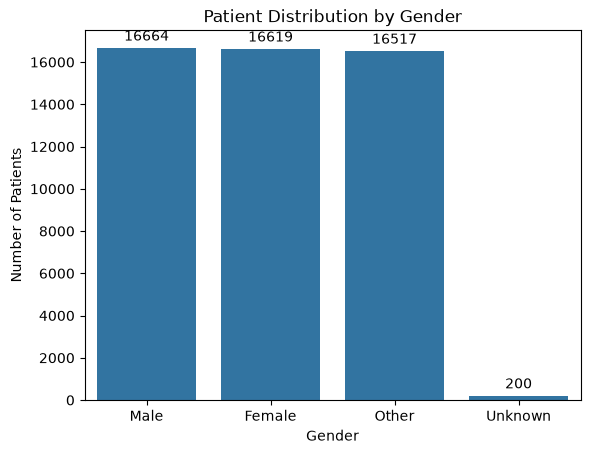

In [141]:
ax = sns.countplot(
    data=patients,
    x="Gender"
)

plt.title("Patient Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

# Add count labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.show()

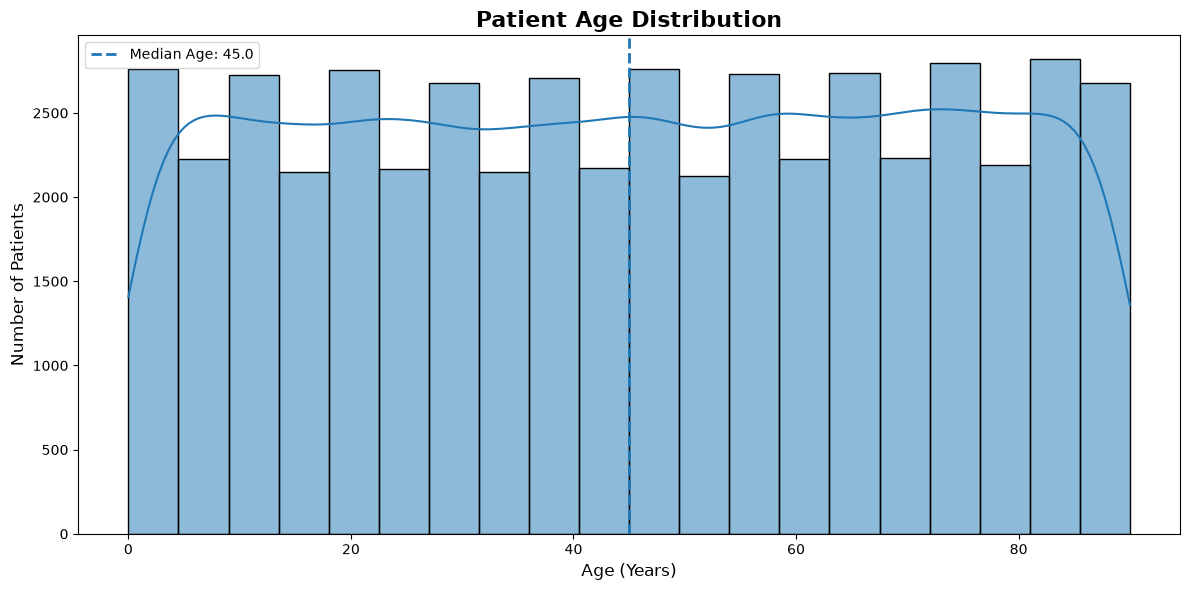

In [142]:
plt.figure(figsize=(12, 6))

ax = sns.histplot(
    data=patients,
    x="Age",
    bins=20,
    kde=True
)

# Add median age line
median_age = patients["Age"].median()

plt.axvline(
    median_age,
    linestyle="--",
    linewidth=2,
    label=f"Median Age: {median_age:.1f}"
)

plt.title("Patient Age Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Age (Years)", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()

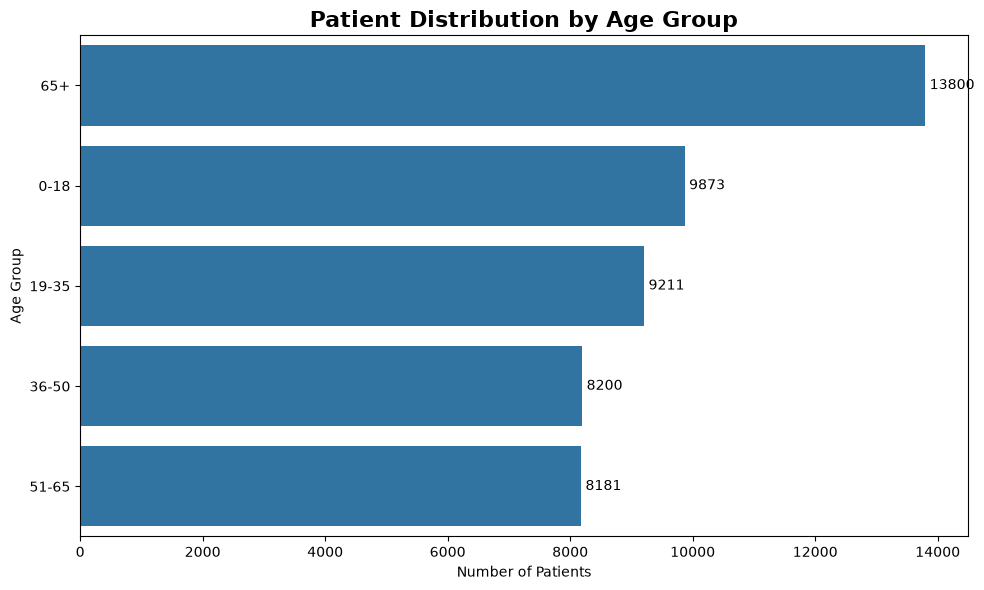

In [143]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=patients,
    y="Age_Group",
    order=patients["Age_Group"].value_counts().index
)

plt.title("Patient Distribution by Age Group", fontsize=16, fontweight="bold")
plt.xlabel("Number of Patients")
plt.ylabel("Age Group")

# Add values
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

In [147]:
city_counts = patients["City"].value_counts()

city_counts.head(10)

City
Bengaluru    7249
Chennai      7229
Mumbai       7165
Pune         7150
Hyderabad    7120
Kolkata      7074
Delhi        7013
Name: count, dtype: int64

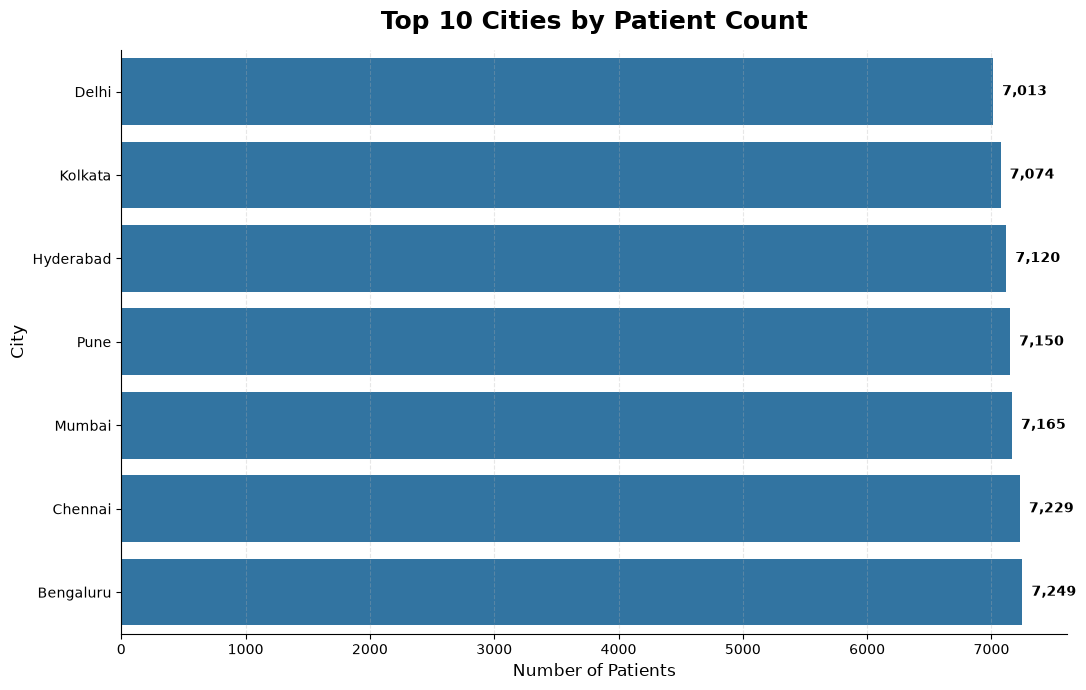

In [149]:
# Top 10 cities
top_cities = city_counts.head(10).sort_values(ascending=True)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

# Add patient counts
for i, value in enumerate(top_cities.values):
    ax.text(
        value + top_cities.max() * 0.01,
        i,
        f"{value:,}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Top 10 Cities by Patient Count",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Patients", fontsize=12)
plt.ylabel("City", fontsize=12)

# Clean look
sns.despine()
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [150]:
patients["Insurance"].value_counts()

Insurance
Corporate     12605
Self Pay      12564
Government    12499
Private       12332
Name: count, dtype: int64

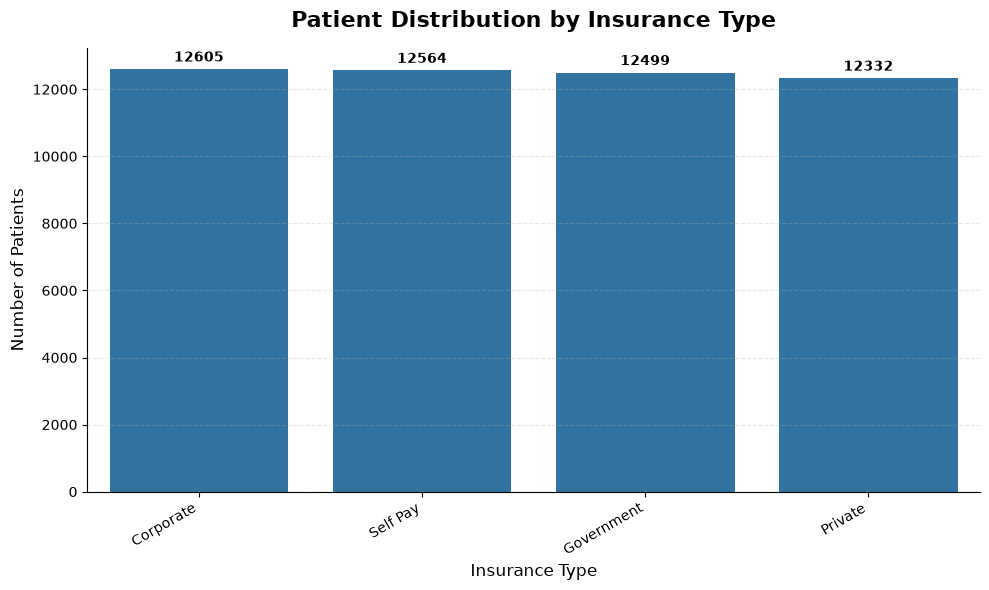

In [151]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=patients,
    x="Insurance",
    order=patients["Insurance"].value_counts().index
)

# Add count labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3,
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Patient Distribution by Insurance Type",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Insurance Type", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

plt.xticks(rotation=30, ha="right")

# Clean dashboard-style appearance
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [152]:
visits["Visit_Type"].value_counts()

Visit_Type
Inpatient     45164
Emergency     45113
Follow-Up     44898
Outpatient    44825
Name: count, dtype: int64

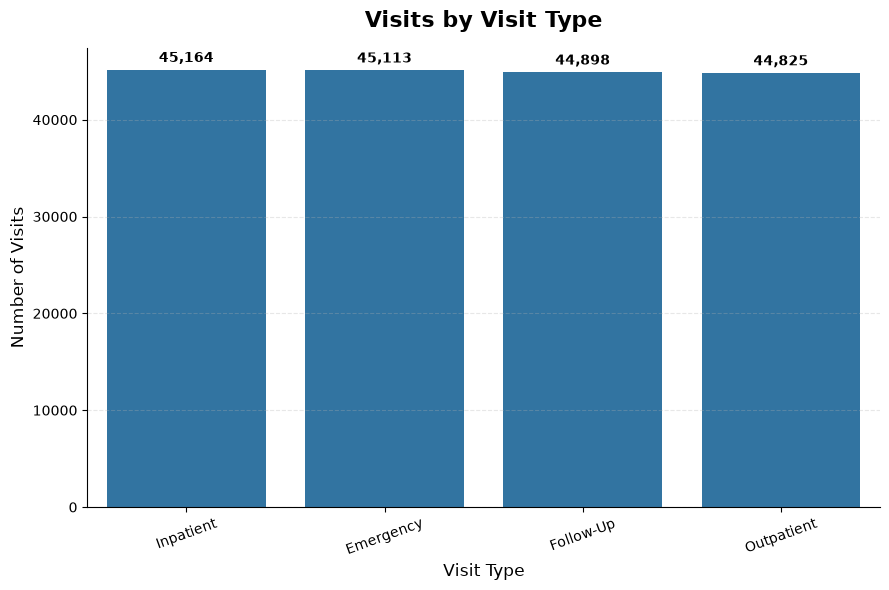

In [153]:
# Count visits by type
visit_counts = visits["Visit_Type"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=visit_counts.index,
    y=visit_counts.values
)

# Add count labels
for i, value in enumerate(visit_counts.values):
    ax.text(
        i,
        value + visit_counts.max() * 0.01,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Visits by Visit Type",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Visit Type", fontsize=12)
plt.ylabel("Number of Visits", fontsize=12)

plt.xticks(rotation=20)

# Clean look
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [154]:
diagnosis_counts = visits["Diagnosis"].value_counts()

diagnosis_counts

Diagnosis
Routine Check    22912
Heart Disease    22704
Asthma           22498
Migraine         22446
Fracture         22445
Hypertension     22346
Infection        22330
Diabetes         22319
Name: count, dtype: int64

In [155]:
diagnosis_counts.head(10)

Diagnosis
Routine Check    22912
Heart Disease    22704
Asthma           22498
Migraine         22446
Fracture         22445
Hypertension     22346
Infection        22330
Diabetes         22319
Name: count, dtype: int64

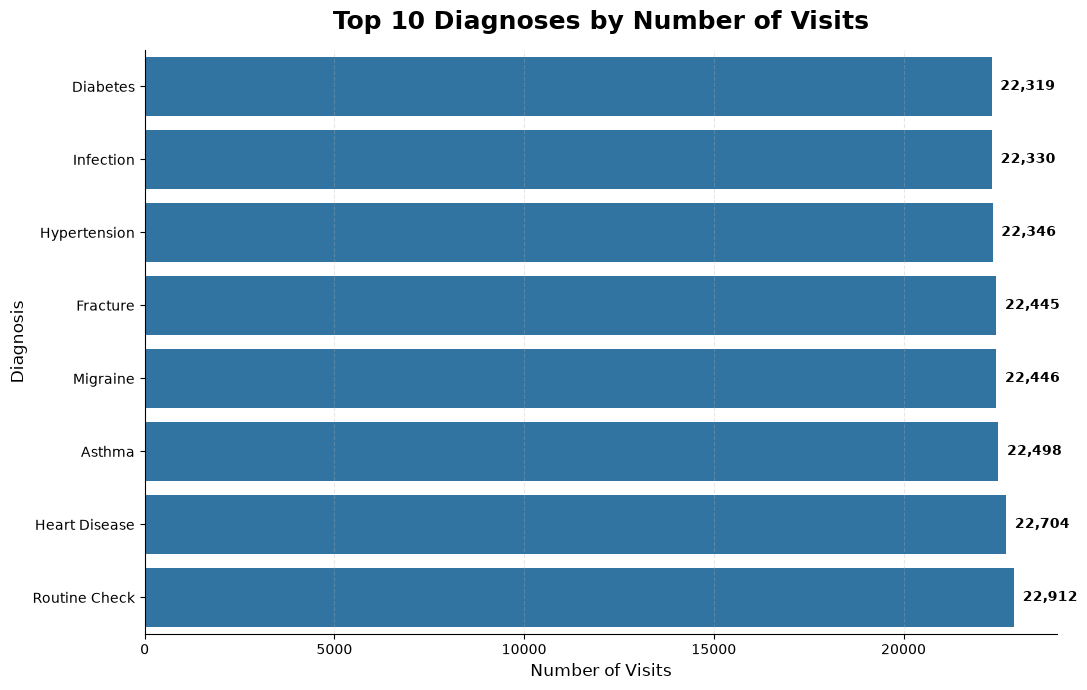

In [156]:
# Top 10 diagnoses
top_diagnoses = diagnosis_counts.head(10).sort_values(ascending=True)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    x=top_diagnoses.values,
    y=top_diagnoses.index
)

# Add visit counts
for i, value in enumerate(top_diagnoses.values):
    ax.text(
        value + top_diagnoses.max() * 0.01,
        i,
        f"{value:,}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Top 10 Diagnoses by Number of Visits",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Visits", fontsize=12)
plt.ylabel("Diagnosis", fontsize=12)

# Clean professional appearance
sns.despine()
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [157]:
visits["Bill_Amount"].sum()

np.float64(1892730347.98)

In [158]:
visits["Bill_Amount"].mean()

np.float64(10515.16859988889)

In [159]:
visits["Bill_Amount"].median()

np.float64(9393.255000000001)

In [160]:
visits["Bill_Amount"].max()

np.float64(55526.4)

In [161]:
visits["Bill_Amount"].min()

np.float64(67.31)

In [162]:
revenue_by_visit = visits.groupby(
    "Visit_Type"
)["Bill_Amount"].agg(
    ["sum", "mean", "count"]
).sort_values(
    "sum",
    ascending=False
)

revenue_by_visit

,sum,mean,count
Visit_Type,,,
Inpatient,4.756430e+08,10531.463014,45164
Emergency,4.751500e+08,10532.440093,45113
Outpatient,4.713813e+08,10516.035563,44825
Follow-Up,4.705561e+08,10480.557895,44898


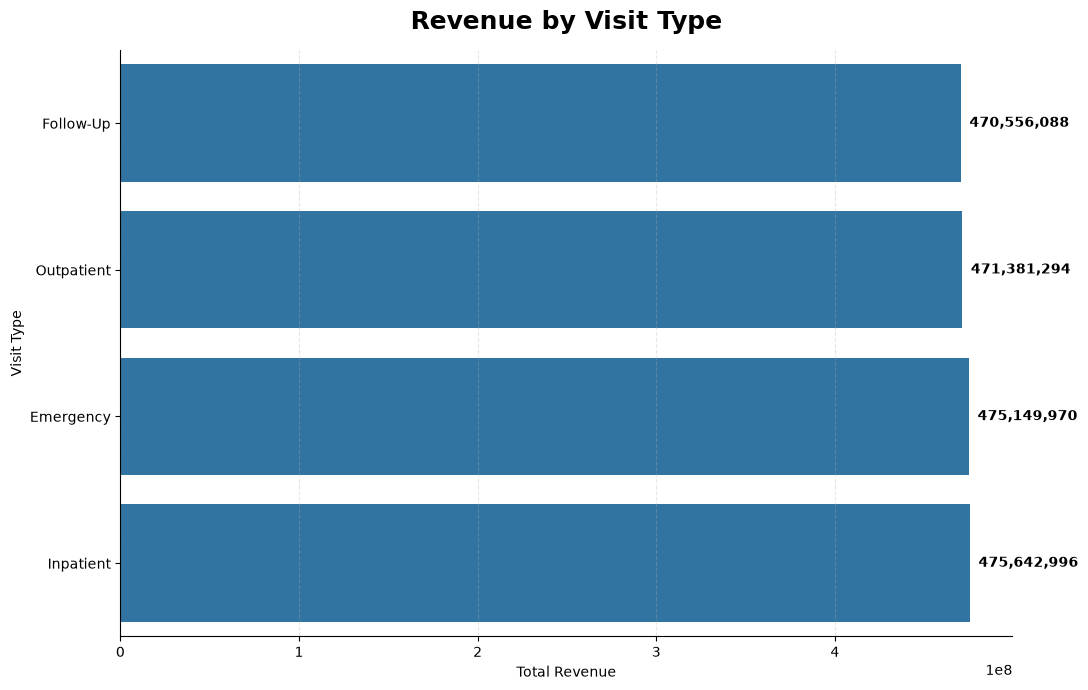

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort revenue from smallest to largest
revenue_plot = (
    revenue_by_visit
    .sort_values(by="sum", ascending=True)
    .reset_index()
)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=revenue_plot,
    x="sum",
    y="Visit_Type"
)

# Add revenue labels
for i, value in enumerate(revenue_plot["sum"]):
    ax.text(
        value + revenue_plot["sum"].max() * 0.01,
        i,
        f"{value:,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Revenue by Visit Type",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Total Revenue")
plt.ylabel("Visit Type")

sns.despine()
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [165]:
visits["Length_of_Stay"].describe()

count    180000.000000
mean          7.488128
std           4.612748
min           0.000000
25%           3.000000
50%           8.000000
75%          11.000000
max          15.000000
Name: Length_of_Stay, dtype: float64

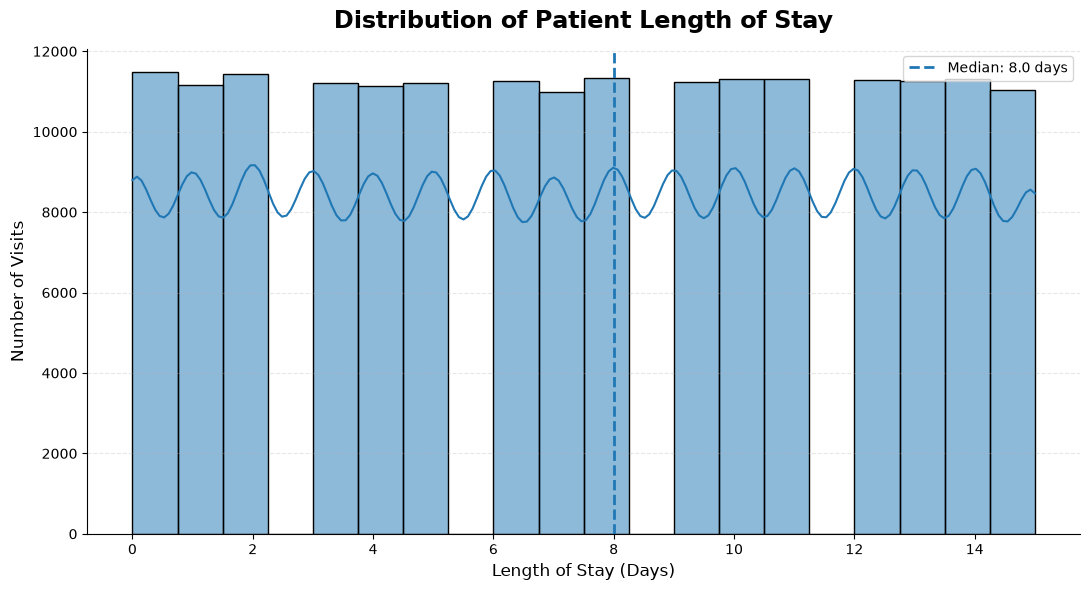

In [166]:
plt.figure(figsize=(11, 6))

ax = sns.histplot(
    data=visits,
    x="Length_of_Stay",
    bins=20,
    kde=True
)

# Calculate median
median_los = visits["Length_of_Stay"].median()

# Add median line
plt.axvline(
    median_los,
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_los:.1f} days"
)

plt.title(
    "Distribution of Patient Length of Stay",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Length of Stay (Days)", fontsize=12)
plt.ylabel("Number of Visits", fontsize=12)

plt.legend()

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

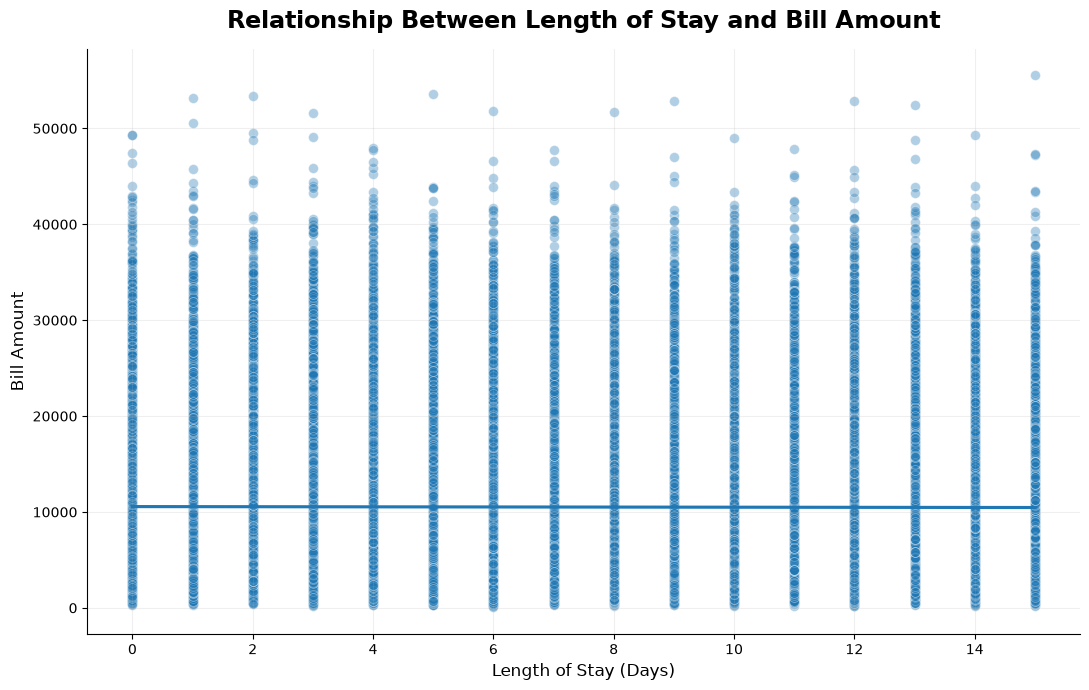

In [167]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=visits,
    x="Length_of_Stay",
    y="Bill_Amount",
    alpha=0.35,
    s=50
)

# Add trend line
sns.regplot(
    data=visits,
    x="Length_of_Stay",
    y="Bill_Amount",
    scatter=False,
    ci=None
)

plt.title(
    "Relationship Between Length of Stay and Bill Amount",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Length of Stay (Days)", fontsize=12)
plt.ylabel("Bill Amount", fontsize=12)

sns.despine()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [168]:
admissions["Admission_Type"].value_counts()

Admission_Type
Elective     16924
Transfer     16672
Emergency    16404
Name: count, dtype: int64

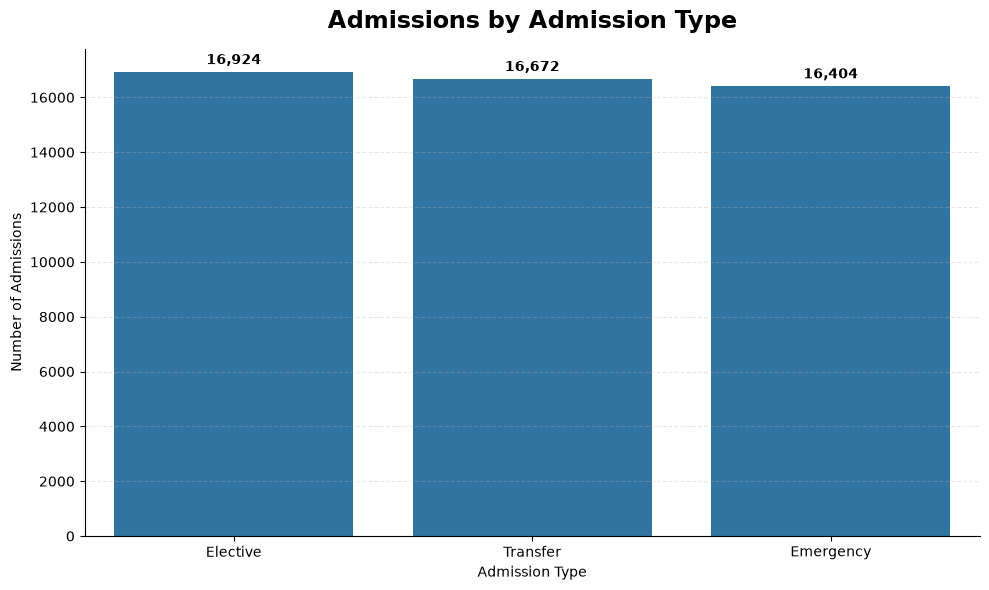

In [169]:
# Count admissions by type
admission_counts = (
    admissions["Admission_Type"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=admission_counts.index,
    y=admission_counts.values
)

# Add count labels
for i, value in enumerate(admission_counts.values):
    ax.text(
        i,
        value + admission_counts.max() * 0.01,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Admissions by Admission Type",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Admission Type")
plt.ylabel("Number of Admissions")

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# addmission analysis

In [170]:
admissions["Admission_Type"].value_counts()

Admission_Type
Elective     16924
Transfer     16672
Emergency    16404
Name: count, dtype: int64

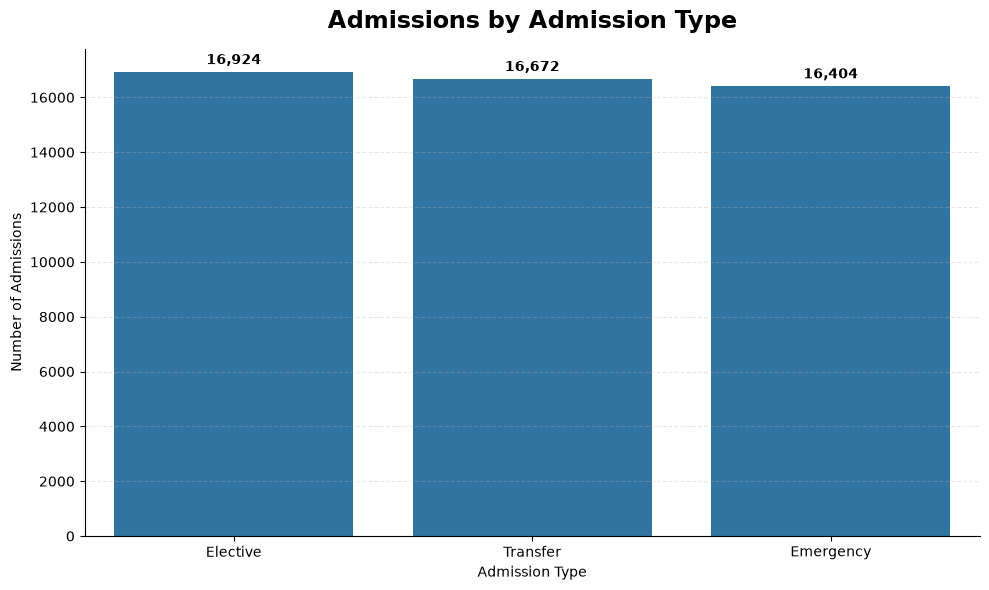

In [171]:
# Count admission types
admission_counts = admissions["Admission_Type"].value_counts()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=admission_counts.index,
    y=admission_counts.values
)

# Add values on bars
for i, value in enumerate(admission_counts.values):
    ax.text(
        i,
        value + admission_counts.max() * 0.01,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Admissions by Admission Type",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Admission Type")
plt.ylabel("Number of Admissions")

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# ward analysis

In [172]:
admissions["Ward"].value_counts()

Ward
Private         10139
General         10024
Semi Private    10014
Emergency        9935
ICU              9888
Name: count, dtype: int64

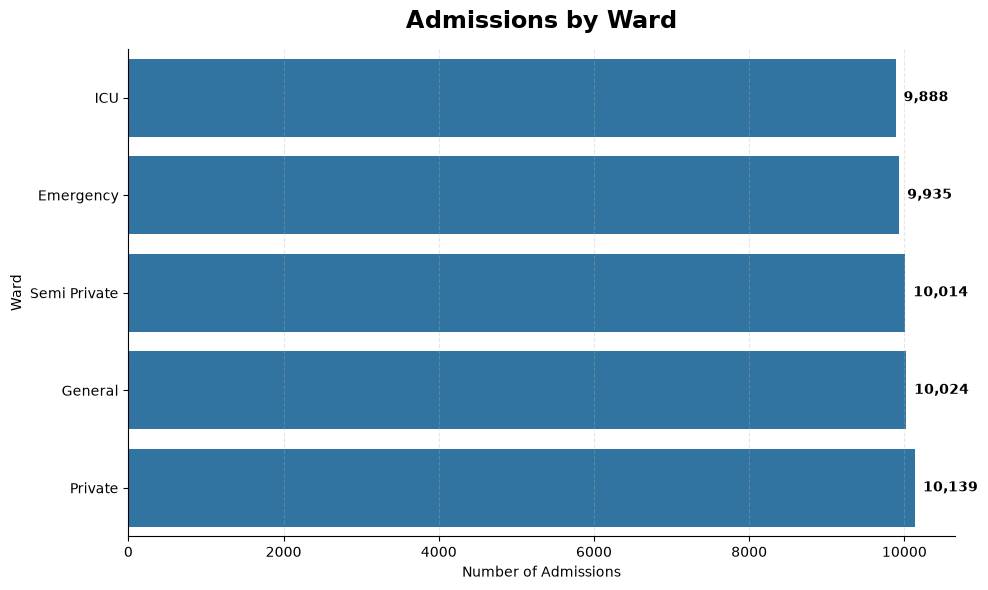

In [173]:
# Count admissions by ward
ward_counts = (
    admissions["Ward"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=ward_counts.values,
    y=ward_counts.index
)

# Add admission counts
for i, value in enumerate(ward_counts.values):
    ax.text(
        value + ward_counts.max() * 0.01,
        i,
        f"{value:,}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Admissions by Ward",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Admissions")
plt.ylabel("Ward")

sns.despine()
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Discharge status

In [174]:
admissions["Discharge_Status"].value_counts()

Discharge_Status
Home        40991
Referred     4018
Transfer     3981
Expired      1010
Name: count, dtype: int64

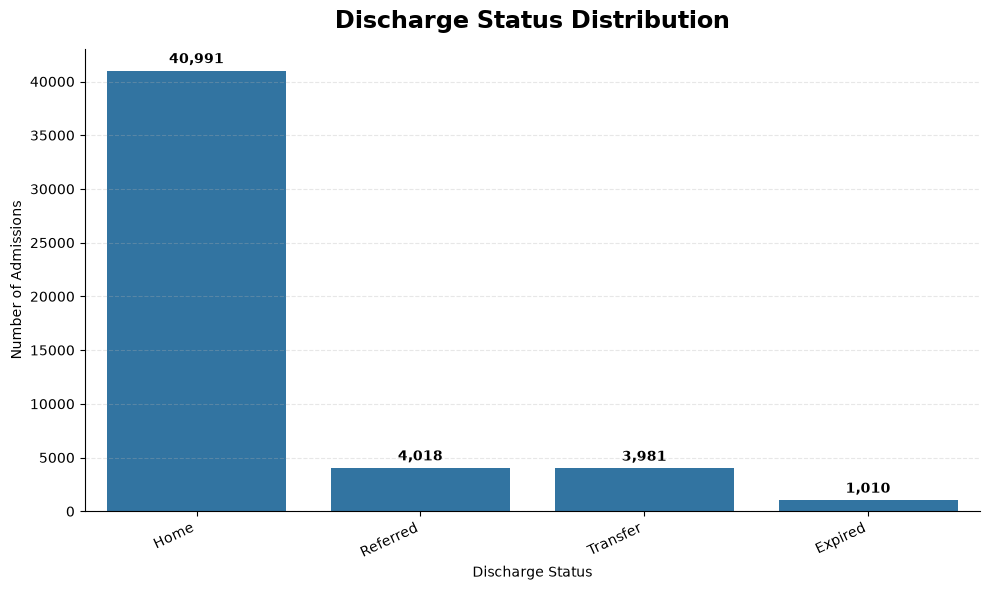

In [175]:
# Count discharge status
discharge_counts = (
    admissions["Discharge_Status"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=discharge_counts.index,
    y=discharge_counts.values
)

# Add counts on bars
for i, value in enumerate(discharge_counts.values):
    ax.text(
        i,
        value + discharge_counts.max() * 0.01,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Discharge Status Distribution",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Discharge Status")
plt.ylabel("Number of Admissions")

plt.xticks(rotation=25, ha="right")

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# DOCTOR ANALYSIS

In [176]:
doctors["Specialty"].value_counts()

Specialty
Dermatology         657
Oncology            651
ENT                 646
Pediatrics          628
Neurology           610
Cardiology          606
General Medicine    602
Orthopedics         600
Name: count, dtype: int64

In [177]:
lab_tests["Test_Name"].value_counts()

Test_Name
CT Scan          27998
MRI              27876
LFT              27870
TSH              27838
CBC              27813
HbA1c            27737
X-Ray            27711
KFT              27687
Lipid Profile    27470
Name: count, dtype: int64

total_patients = patients["Patient_ID"].nunique()
total_patients


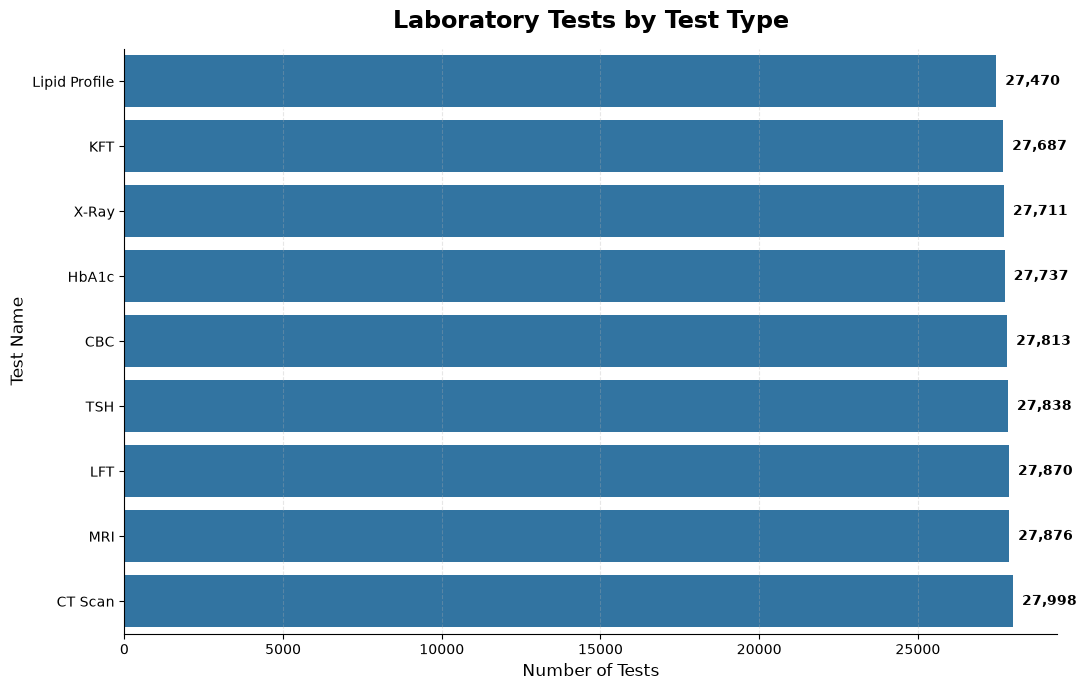

In [178]:
# Count tests and sort
test_counts = (
    lab_tests["Test_Name"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    x=test_counts.values,
    y=test_counts.index
)

# Add count labels
for i, value in enumerate(test_counts.values):
    ax.text(
        value + test_counts.max() * 0.01,
        i,
        f"{value:,}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Laboratory Tests by Test Type",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Tests", fontsize=12)
plt.ylabel("Test Name", fontsize=12)

sns.despine()
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [179]:
lab_tests["Result_Status"].value_counts()

Result_Status
Normal    248916
Low          559
High         525
Name: count, dtype: int64

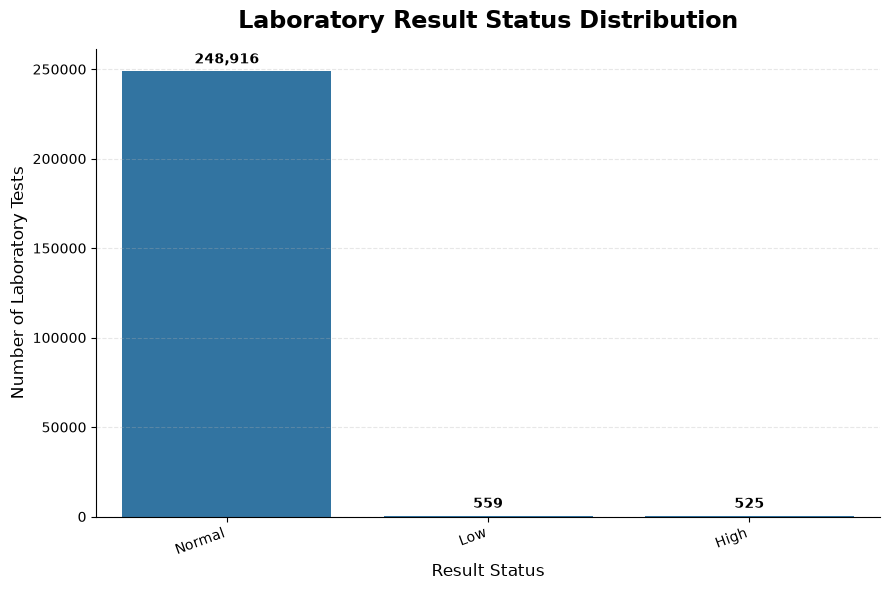

In [180]:
result_counts = (
    lab_tests["Result_Status"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=result_counts.index,
    y=result_counts.values
)

# Add value labels
for i, value in enumerate(result_counts.values):
    ax.text(
        i,
        value + result_counts.max() * 0.01,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Laboratory Result Status Distribution",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Result Status", fontsize=12)
plt.ylabel("Number of Laboratory Tests", fontsize=12)

plt.xticks(rotation=20, ha="right")

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [181]:
total_visits = visits["Visit_ID"].nunique()
total_visits

180000

In [182]:
total_admissions = admissions["Admission_ID"].nunique()
total_admissions

50000

In [183]:
total_revenue = visits["Bill_Amount"].sum()
total_revenue

np.float64(1892730347.98)

In [184]:
average_bill = visits["Bill_Amount"].mean()
average_bill

np.float64(10515.16859988889)

In [185]:
average_bill = visits["Bill_Amount"].mean()
average_bill

np.float64(10515.16859988889)

In [186]:
total_lab_tests = lab_tests["Lab_Test_ID"].nunique()
total_lab_tests

250000

In [194]:
abnormal_test_rate = (
    lab_tests["Abnormal_Flag"].mean() * 100
)

abnormal_test_rate

np.float64(22.094)

In [196]:
prescriptions["Total_Cost"] = (
    prescriptions["Days_Supply"] * prescriptions["Unit_Cost"]
)

In [197]:
prescriptions["Total_Cost"] = (
    prescriptions["Days_Supply"] * prescriptions["Unit_Cost"]
)

In [198]:
prescriptions["Total_Cost"] = (
    prescriptions["Days_Supply"] * prescriptions["Unit_Cost"]
)

In [199]:
total_medication_cost = prescriptions["Total_Cost"].sum()
total_medication_cost

np.float64(4018389711.1400003)

In [200]:
total_medication_cost = prescriptions["Total_Cost"].sum()
total_medication_cost

np.float64(4018389711.1400003)

In [201]:
kpis = {
    "Total Patients": patients["Patient_ID"].nunique(),
    "Total Visits": visits["Visit_ID"].nunique(),
    "Total Admissions": admissions["Admission_ID"].nunique(),
    "Total Revenue": visits["Bill_Amount"].sum(),
    "Average Bill": visits["Bill_Amount"].mean(),
    "Average Length of Stay": visits["Length_of_Stay"].mean(),
    "Total Lab Tests": lab_tests["Lab_Test_ID"].nunique(),
    "Abnormal Test Rate": lab_tests["Abnormal_Flag"].mean() * 100,
    "Total Medication Cost": prescriptions["Total_Cost"].sum(),
    "Total Doctors": doctors["Doctor_ID"].nunique()
}

kpis

{'Total Patients': 50000,
 'Total Visits': 180000,
 'Total Admissions': 50000,
 'Total Revenue': np.float64(1892730347.98),
 'Average Bill': np.float64(10515.16859988889),
 'Average Length of Stay': np.float64(7.488127777777778),
 'Total Lab Tests': 250000,
 'Abnormal Test Rate': np.float64(22.094),
 'Total Medication Cost': np.float64(4018389711.1400003),
 'Total Doctors': 5000}

# Time-series analysis

In [202]:
monthly_visits = (
    visits
    .set_index("Visit_Date")
    .resample("ME")
    .agg(
        Visits=("Visit_ID", "count"),
        Revenue=("Bill_Amount", "sum")
    )
    .reset_index()
)

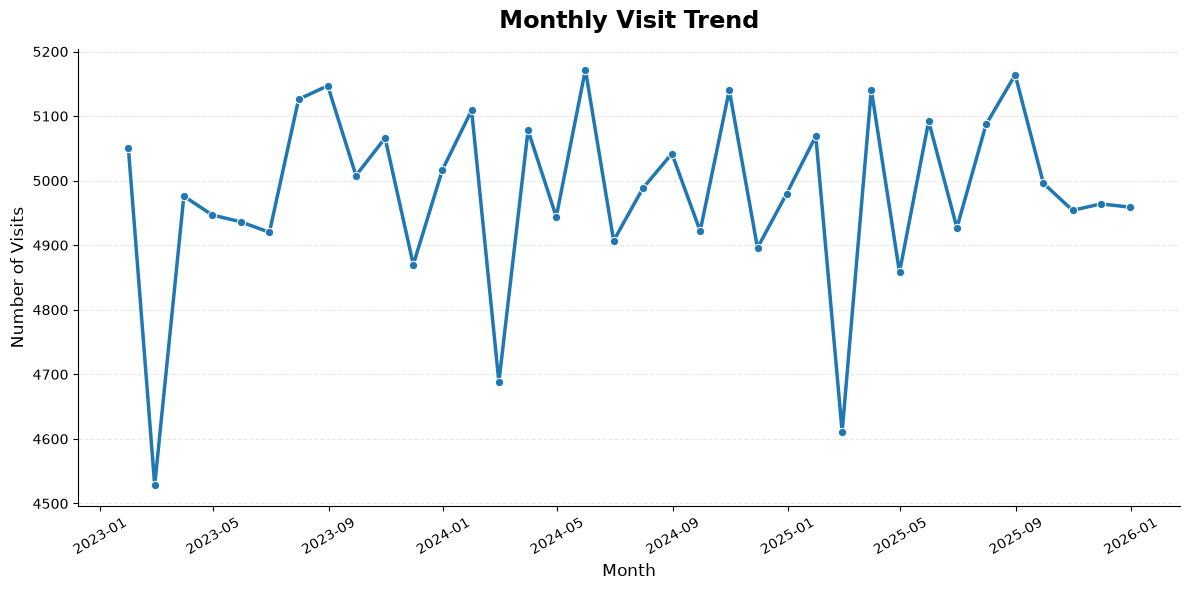

In [204]:
plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=monthly_visits,
    x="Visit_Date",
    y="Visits",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Monthly Visit Trend",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Visits", fontsize=12)

plt.xticks(rotation=30)

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [205]:
for x, y in zip(monthly_visits["Visit_Date"], monthly_visits["Revenue"]):
    ax.annotate(
        f"{y:,.0f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9
    )

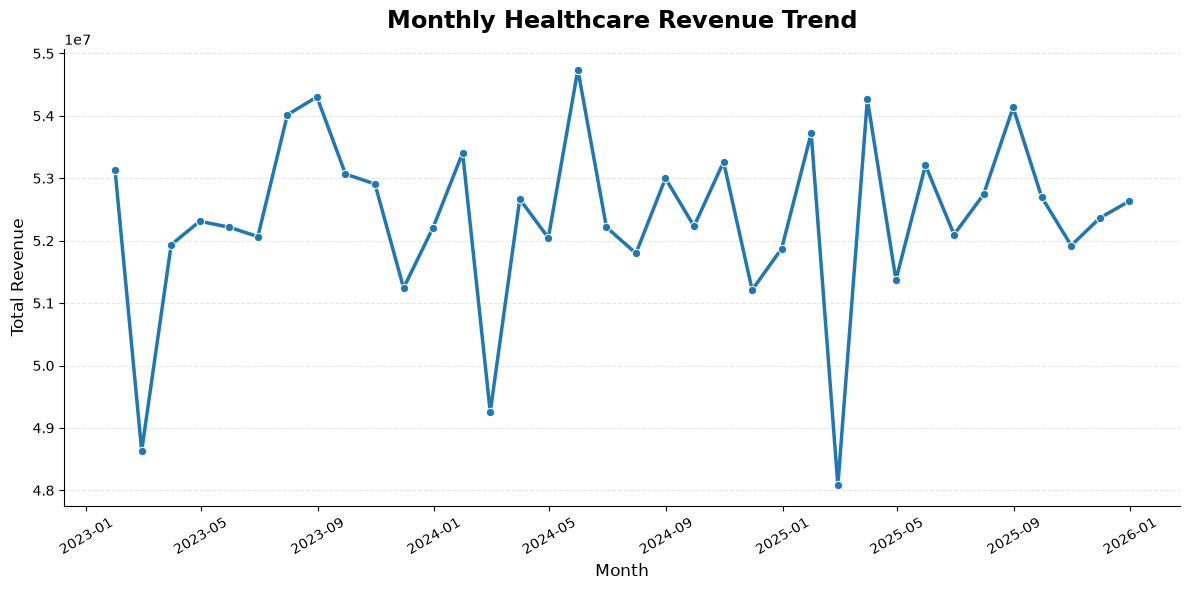

In [206]:
# Make sure months are in chronological order
monthly_visits = monthly_visits.sort_values("Visit_Date")

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=monthly_visits,
    x="Visit_Date",
    y="Revenue",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Monthly Healthcare Revenue Trend",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)

plt.xticks(rotation=30)

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [207]:
diagnosis_revenue = visits.groupby(
    "Diagnosis"
).agg(
    Visits=("Visit_ID", "count"),
    Revenue=("Bill_Amount", "sum"),
    Average_Bill=("Bill_Amount", "mean")
).sort_values(
    "Revenue",
    ascending=False
)

diagnosis_revenue

,Visits,Revenue,Average_Bill
Diagnosis,,,
Routine Check,22912,2.402194e+08,10484.434205
Heart Disease,22704,2.385507e+08,10506.989522
Asthma,22498,2.370214e+08,10535.219562
Migraine,22446,2.366563e+08,10543.363501
Infection,22330,2.354928e+08,10546.029890
Diabetes,22319,2.350869e+08,10533.038767
Hypertension,22346,2.349969e+08,10516.283350
Fracture,22445,2.347060e+08,10456.938609


In [208]:
numeric_cols = [
    "Age",
    "Bill_Amount",
    "Length_of_Stay"
]

corr = patient_visits[numeric_cols].corr()

corr

,Age,Bill_Amount,Length_of_Stay
Age,NaN,NaN,NaN
Bill_Amount,NaN,1.000000,-0.004901
Length_of_Stay,NaN,-0.004901,1.000000


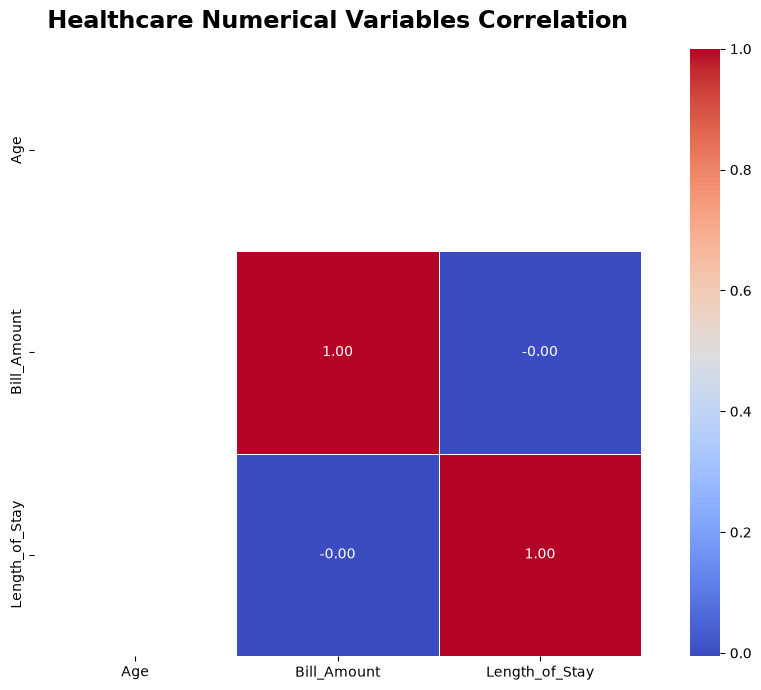

In [209]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title(
    "Healthcare Numerical Variables Correlation",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

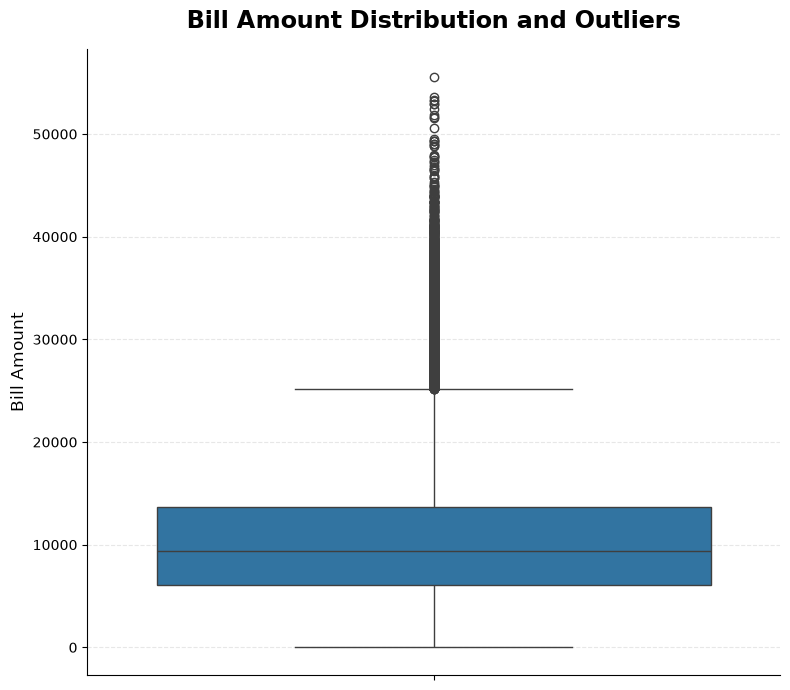

In [210]:
plt.figure(figsize=(8, 7))

sns.boxplot(
    data=visits,
    y="Bill_Amount"
)

plt.title(
    "Bill Amount Distribution and Outliers",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.ylabel("Bill Amount", fontsize=12)

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

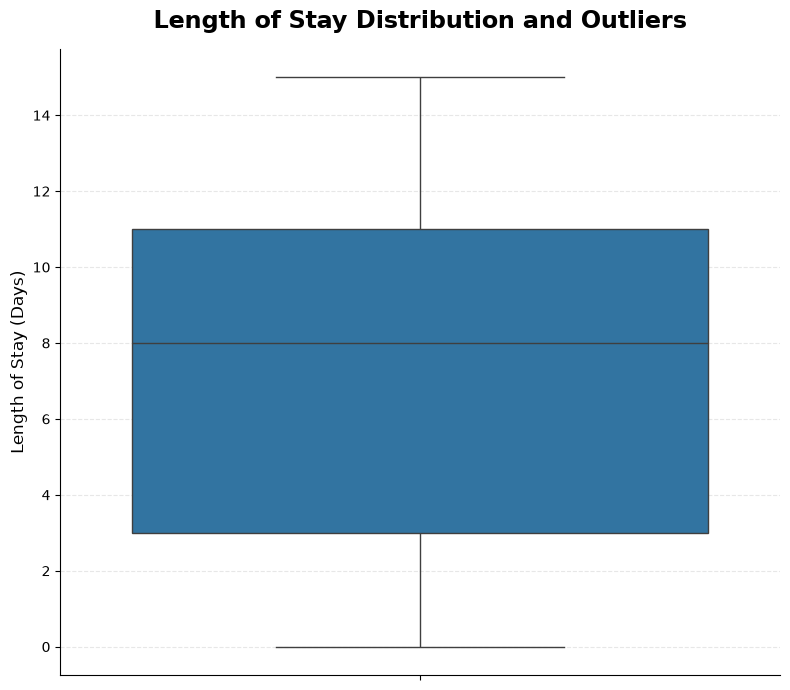

In [211]:
plt.figure(figsize=(8, 7))

sns.boxplot(
    data=visits,
    y="Length_of_Stay"
)

plt.title(
    "Length of Stay Distribution and Outliers",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.ylabel("Length of Stay (Days)", fontsize=12)

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [212]:
Q1 = visits["Bill_Amount"].quantile(0.25)
Q3 = visits["Bill_Amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = visits[
    (visits["Bill_Amount"] < lower) |
    (visits["Bill_Amount"] > upper)
]

outliers.shape

(4569, 12)

In [213]:
summary = {
    "Metric": [
        "Total Patients",
        "Total Visits",
        "Total Admissions",
        "Total Doctors",
        "Total Staff",
        "Total Lab Tests",
        "Total Prescriptions",
        "Total Revenue",
        "Average Bill",
        "Average Length of Stay",
        "Abnormal Lab Rate"
    ],
    
    "Value": [
        patients["Patient_ID"].nunique(),
        visits["Visit_ID"].nunique(),
        admissions["Admission_ID"].nunique(),
        doctors["Doctor_ID"].nunique(),
        staff["Staff_ID"].nunique(),
        lab_tests["Lab_Test_ID"].nunique(),
        prescriptions["Prescription_ID"].nunique(),
        visits["Bill_Amount"].sum(),
        visits["Bill_Amount"].mean(),
        visits["Length_of_Stay"].mean(),
        lab_tests["Abnormal_Flag"].mean() * 100
    ]
}

kpi_table = pd.DataFrame(summary)

kpi_table

,Metric,Value
0,Total Patients,5.000000e+04
1,Total Visits,1.800000e+05
2,Total Admissions,5.000000e+04
3,Total Doctors,5.000000e+03
4,Total Staff,1.000000e+04
5,Total Lab Tests,2.500000e+05
6,Total Prescriptions,2.200000e+05
7,Total Revenue,1.892730e+09
8,Average Bill,1.051517e+04
9,Average Length of Stay,7.488128e+00


In [125]:
patients.to_csv("patients_cleaned.csv", index=False)
visits.to_csv("visits_cleaned.csv", index=False)
admissions.to_csv("admissions_cleaned.csv", index=False)
doctors.to_csv("doctors_cleaned.csv", index=False)
lab_tests.to_csv("lab_tests_cleaned.csv", index=False)
prescriptions.to_csv("prescriptions_cleaned.csv", index=False)
staff.to_csv("staff_cleaned.csv", index=False)

In [126]:
import os

for file in [
    "patients_cleaned.csv",
    "visits_cleaned.csv",
    "admissions_cleaned.csv",
    "doctors_cleaned.csv",
    "lab_tests_cleaned.csv",
    "prescriptions_cleaned.csv",
    "staff_cleaned.csv"
]:
    print(file, os.path.exists(file))

patients_cleaned.csv True
visits_cleaned.csv True
admissions_cleaned.csv True
doctors_cleaned.csv True
lab_tests_cleaned.csv True
prescriptions_cleaned.csv True
staff_cleaned.csv True
